# Overview of anomalies

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from autoencoders.ae import AutoEncoder
from anomaly.metrics import Reconstruction


from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [3]:
mse_cols = ['mse', 'mse_filter_250', 'mse_97', 'mse_filter_250_97']
mse_rel_cols = ['mse_rel', 'mse_filter_250_rel', 'mse_97_rel', 'mse_filter_250_97_rel']

In [4]:
mse_family = ['mse', 'mse_97', 'mse_filter_250', 'mse_filter_250_97']
chi_sq_family = ['mse_rel', 'mse_97_rel', 'mse_filter_250_rel', 'mse_filter_250_97_rel']

# Custom functions

# Config

## Directories

In [5]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_ids = [f"bin_{i:02d}" for i in range(4)]

## Data

In [6]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)

In [7]:
spectra_03 = np.load(
    f"{spectra_dir}/bin_03/bin_03_fluxes.npy",
    mmap_mode="r"
)

spectra_03_rec = np.load(
    f"{spectra_dir}/bin_03/bin_03_rec_fluxes.npy",
    mmap_mode="r"
)

idx_id_spec_03 = np.load(
    f"{spectra_dir}/bin_03/bin_03_index_specobjid.npy",
    mmap_mode='r'
)

In [8]:
bin_id = 'bin_03'
score_03_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)
n_spec = score_03_df.shape[0]
n_top_1_pct = int(n_spec*0.01)
n_top_1_pct

1818

In [9]:
rank = np.arange(score_03_df.shape[0]).astype(int)
score_03_rank_df = score_03_df.copy()

cols_dtypes_dict = {}

for col in score_03_df.columns:

    index_sorted = score_03_df.sort_values(
        by=col, ascending=False
    ).index

    rank_col = f'rank_{col}'
    
    cols_dtypes_dict[rank_col] = 'int'
    cols_dtypes_dict[col] = 'float'

    score_03_rank_df.loc[index_sorted, f'rank_{col}'] = rank

In [10]:
score_03_rank_df = score_03_rank_df.astype(cols_dtypes_dict)

In [11]:
score_03_rank_df.dtypes

mse                           float64
mse_filter_250                float64
mse_97                        float64
mse_filter_250_97             float64
mse_rel                       float64
mse_filter_250_rel            float64
mse_97_rel                    float64
mse_filter_250_97_rel         float64
rank_mse                        int64
rank_mse_filter_250             int64
rank_mse_97                     int64
rank_mse_filter_250_97          int64
rank_mse_rel                    int64
rank_mse_filter_250_rel         int64
rank_mse_97_rel                 int64
rank_mse_filter_250_97_rel      int64
dtype: object

## Model

In [12]:
ae_03 = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/bin_03/winner",
)

In [13]:
ae_03.get_architecture_and_model_str()

['256_128_64_12_64_128_256', 'infoVae_rec_3776_alpha_0_lambda_9']

# Test scores

In [14]:
score_03_df.mse.quantile(0.7)

2.651440520864139

In [15]:
score_03_rank_df.loc[637325355518027776, ['mse', 'rank_mse']]

mse          10.495128
rank_mse    189.000000
Name: 637325355518027776, dtype: float64

## VAE rec

mse_manual: 10.492	mse_module:10.492


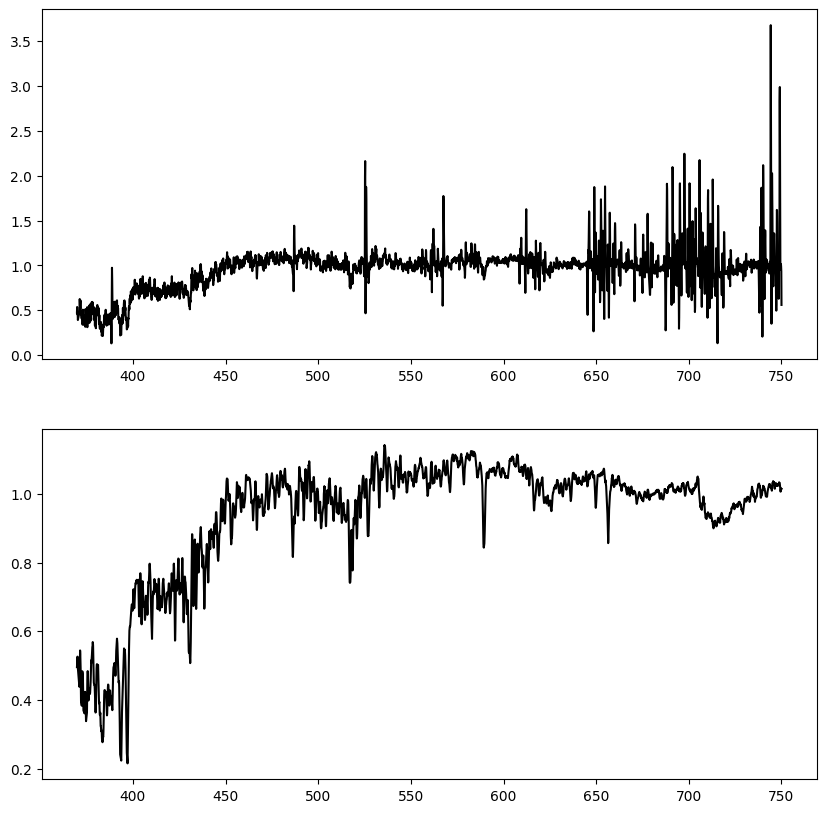

In [16]:
objid = 637325355518027776
spec_idx = specobjid_to_idx(
        objid, idx_id_spec
)
# ----------------------------------------------------

spec = spectra[spec_idx]
rec_spec = ae_03.reconstruct(spec).reshape(-1)

# ----------------------------------------------------
mse_manual = np.sqrt(np.sum((spec - rec_spec)**2))
mse_module = Reconstruction().mse(spec, rec_spec)[0][0]
print(f'mse_manual: {mse_manual:.3f}\tmse_module:{mse_module:.3f}')
# ----------------------------------------------------
fig, ax = plt.subplots(2,1, figsize=(10, 10))


ax[0].plot(wave_nm, spec, color='black')
ax[1].plot(wave_nm, rec_spec, color='black')

plt.show()

# From rec array

mse_manual: 2.633	mse_module:2.633


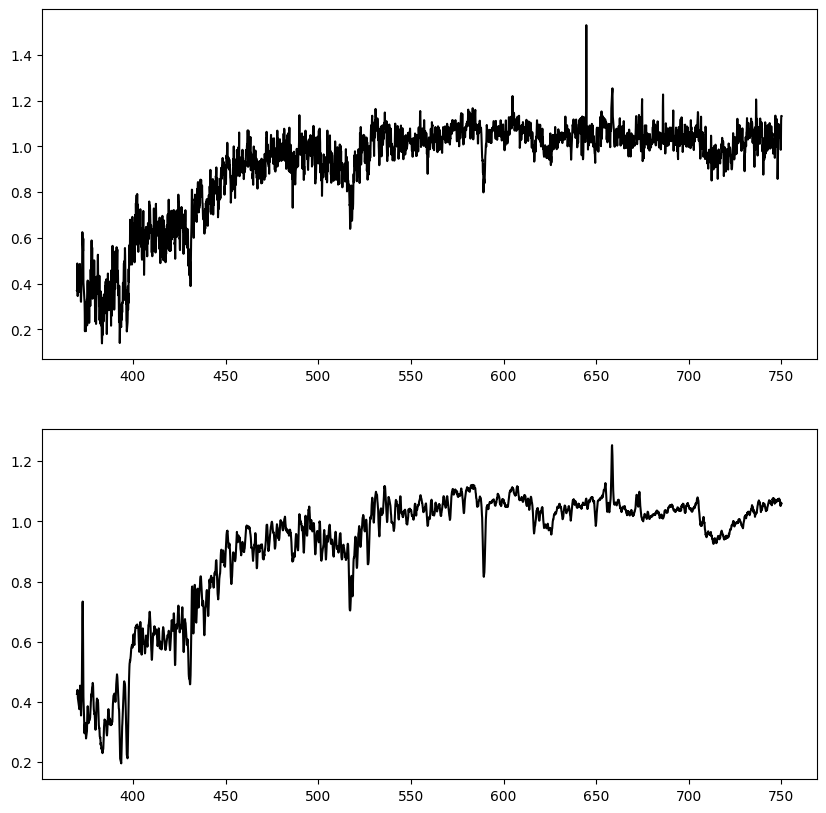

In [17]:
objid = 637325355518027776

spec_idx = specobjid_to_idx(
        objid, idx_id_spec_03
)
# ----------------------------------------------------
spec = spectra_03[spec_idx]
rec_spec = spectra_03_rec[spec_idx]
# ----------------------------------------------------
mse_manual = np.sqrt(np.sum((spec - rec_spec)**2))
mse_module = Reconstruction().mse(spec, rec_spec)[0][0]
print(f'mse_manual: {mse_manual:.3f}\tmse_module:{mse_module:.3f}')
# ----------------------------------------------------
fig, ax = plt.subplots(2,1, figsize=(10, 10))


ax[0].plot(wave_nm, spec, color='black')
ax[1].plot(wave_nm, rec_spec, color='black')

plt.show()

In [22]:
# score_03_df.loc[637325355518027776]
score_03_rank_df.loc[2664004586678806528]

mse                              4.528372
mse_filter_250                   4.495414
mse_97                           3.588450
mse_filter_250_97                3.560444
mse_rel                          4.353893
mse_filter_250_rel               4.324331
mse_97_rel                       3.633560
mse_filter_250_97_rel            3.611339
rank_mse                      2754.000000
rank_mse_filter_250           2587.000000
rank_mse_97                    534.000000
rank_mse_filter_250_97         549.000000
rank_mse_rel                  2286.000000
rank_mse_filter_250_rel       2167.000000
rank_mse_97_rel                541.000000
rank_mse_filter_250_97_rel     548.000000
Name: 2664004586678806528, dtype: float64

# Update rec id array

In [19]:
tata = np.empty(idx_id_spec_03.shape)

tata[:, 1] = idx_id_spec_03[:, 1]
tata[:, 0] = np.arange(idx_id_spec_03.shape[0])

mse_manual: 10.495	mse_module:10.495


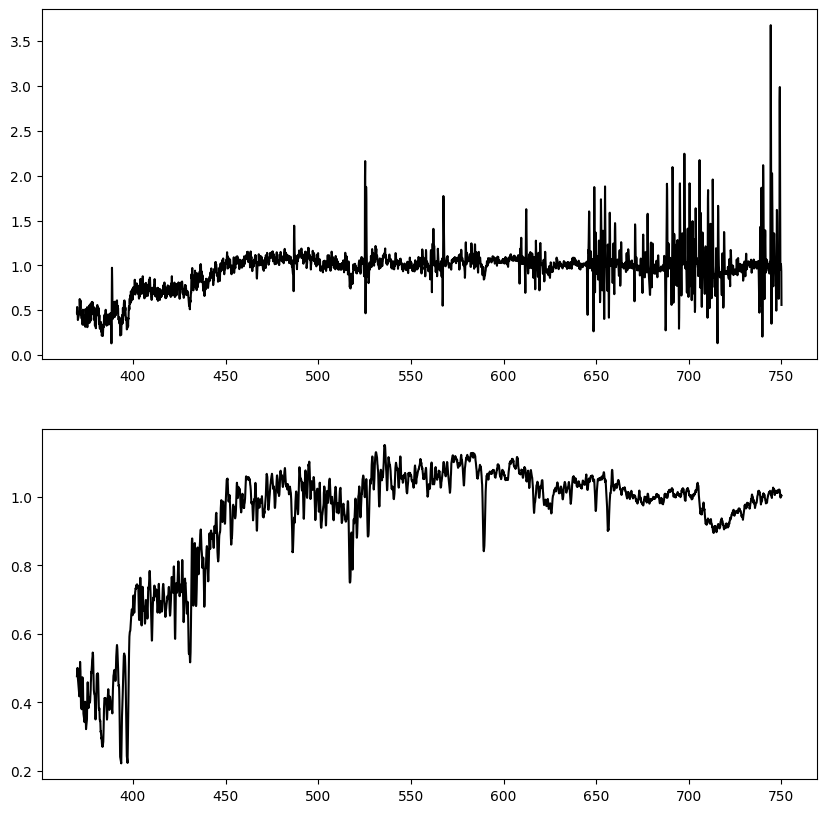

In [20]:
objid = 637325355518027776

spec_idx = specobjid_to_idx(
        objid, tata
)
# ----------------------------------------------------
spec = spectra_03[spec_idx]
rec_spec = spectra_03_rec[spec_idx]
# ----------------------------------------------------
mse_manual = np.sqrt(np.sum((spec - rec_spec)**2))
mse_module = Reconstruction().mse(spec, rec_spec)[0][0]
print(f'mse_manual: {mse_manual:.3f}\tmse_module:{mse_module:.3f}')
# ----------------------------------------------------
fig, ax = plt.subplots(2,1, figsize=(10, 10))


ax[0].plot(wave_nm, spec, color='black')
ax[1].plot(wave_nm, rec_spec, color='black')

plt.show()